In [1]:
# =========================
# Import Required Libraries
# =========================
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Task 1: Load & Explore Data
# =========================

In [2]:
try:
    # Load your downloaded dataset
    df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

    print("✅ Dataset loaded successfully!\n")
    print("First 5 rows:")
    print(df.head())  # Inspect first few rows

    # Check data types and missing values
    print("\nDataset Info:")
    print(df.info())

    print("\nMissing Values:")
    print(df.isnull().sum())

    # Drop or fill missing values
    df = df.dropna()  # or use df.fillna(value)
    print("\nAfter cleaning, missing values per column:")
    print(df.isnull().sum())

except FileNotFoundError:
    print("❌ File not found. Make sure 'Sleep_health_and_lifestyle_dataset.csv' is in the same directory.")
except Exception as e:
    print("⚠️ Error loading dataset:", e)

✅ Dataset loaded successfully!

First 5 rows:
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200      

# =========================
# Task 2: Basic Data Analysis
# =========================

In [4]:
print("\nBasic Statistics:")
print(df.describe())  # Mean, Median, Std, etc.

# Group by gender to find average sleep duration
avg_sleep_by_gender = df.groupby("Gender")["Sleep Duration"].mean()
print("\nAverage Sleep Duration by Gender:")
print(avg_sleep_by_gender)

# Group by occupation to find average stress level
avg_stress_by_job = df.groupby("Occupation")["Stress Level"].mean()
print("\nAverage Stress Level by Occupation:")
print(avg_stress_by_job)



Basic Statistics:
        Person ID         Age  Sleep Duration  Quality of Sleep  \
count  155.000000  155.000000      155.000000        155.000000   
mean   244.761290   46.632258        6.812258          6.870968   
std     91.282997    7.839311        0.773534          1.337325   
min      4.000000   28.000000        5.800000          4.000000   
25%    199.500000   43.000000        6.300000          6.000000   
50%    255.000000   45.000000        6.500000          7.000000   
75%    304.500000   51.000000        7.400000          8.000000   
max    374.000000   59.000000        8.300000          9.000000   

       Physical Activity Level  Stress Level  Heart Rate   Daily Steps  
count               155.000000    155.000000  155.000000    155.000000  
mean                 60.896774      5.767742   71.787097   6765.806452  
std                  20.634158      1.946757    5.187381   1893.921881  
min                  30.000000      3.000000   65.000000   3000.000000  
25%         

## Interesting Finding

Scientists and Software Engineers have the highest average stress level at 8.00, compared to teachers whose level is 4.61

# =========================
# Task 3: Data Visualization
# =========================

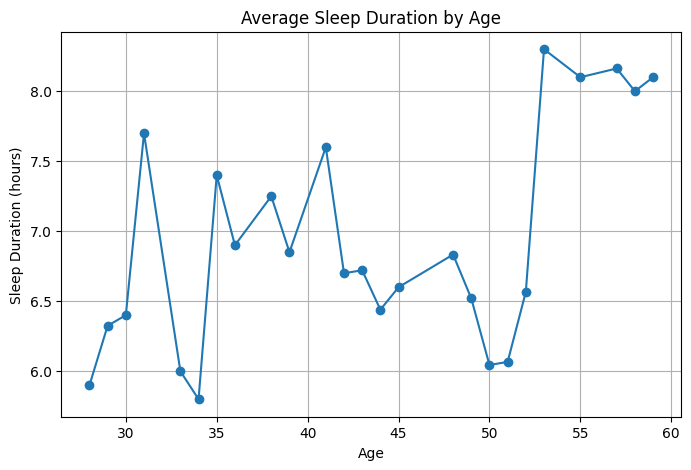

In [6]:
# 1️⃣ Line chart - Average sleep duration by age
avg_sleep_by_age = df.groupby("Age")["Sleep Duration"].mean()
plt.figure(figsize=(8, 5))
plt.plot(avg_sleep_by_age.index, avg_sleep_by_age.values, marker="o")
plt.title("Average Sleep Duration by Age")
plt.xlabel("Age")
plt.ylabel("Sleep Duration (hours)")
plt.grid(True)
plt.show()

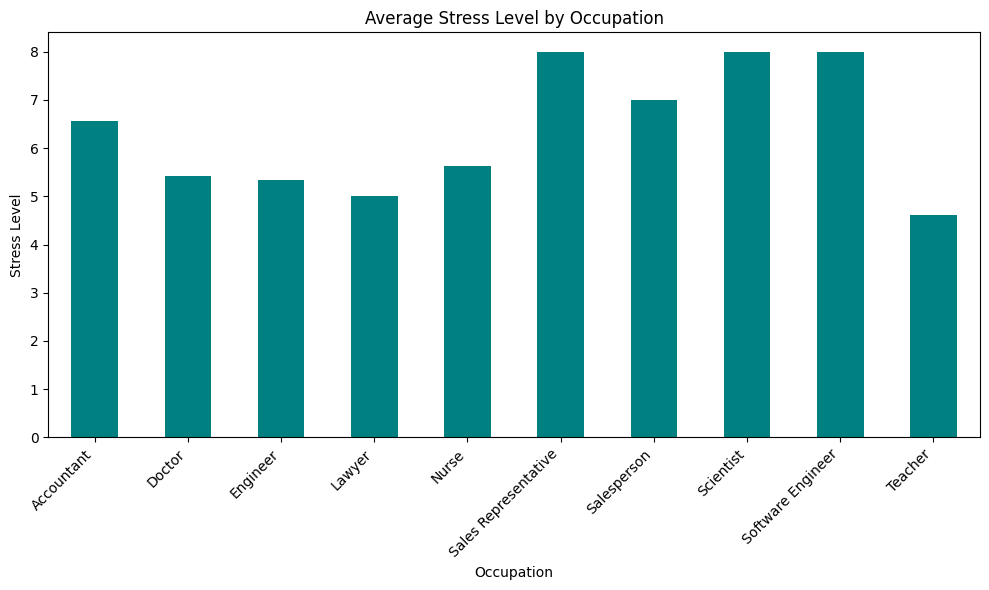

In [7]:
# 2️⃣ Bar chart - Average stress level by occupation
plt.figure(figsize=(10, 6))
avg_stress_by_job.plot(kind="bar", color="teal")
plt.title("Average Stress Level by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Stress Level")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

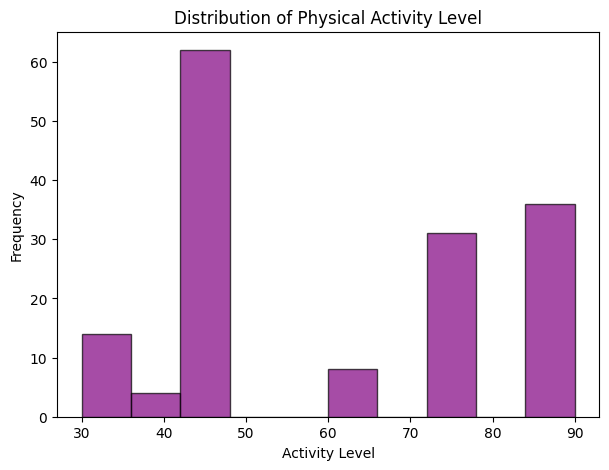

In [9]:
# 3️⃣ Histogram - Distribution of Physical Activity Level
plt.figure(figsize=(7, 5))
plt.hist(df["Physical Activity Level"], bins=10, color="purple", alpha=0.7, edgecolor="black")
plt.title("Distribution of Physical Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Frequency")
plt.show()

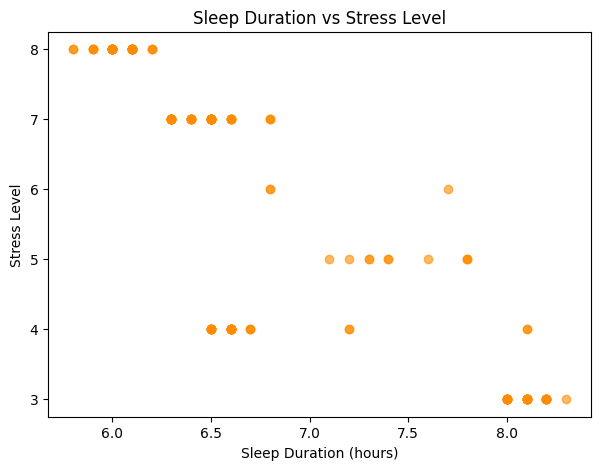

In [10]:
# 4️⃣ Scatter Plot - Sleep Duration vs Stress Level
plt.figure(figsize=(7, 5))
plt.scatter(df["Sleep Duration"], df["Stress Level"], alpha=0.6, color="darkorange")
plt.title("Sleep Duration vs Stress Level")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Stress Level")
plt.show()

In [11]:
# Correlation check
corr = df[["Sleep Duration", "Quality of Sleep", "Physical Activity Level", "Stress Level"]].corr()
print("\nCorrelation Matrix:")
print(corr)


Correlation Matrix:
                         Sleep Duration  Quality of Sleep  \
Sleep Duration                 1.000000          0.916748   
Quality of Sleep               0.916748          1.000000   
Physical Activity Level        0.240760          0.352021   
Stress Level                  -0.848873         -0.872084   

                         Physical Activity Level  Stress Level  
Sleep Duration                          0.240760     -0.848873  
Quality of Sleep                        0.352021     -0.872084  
Physical Activity Level                 1.000000     -0.026627  
Stress Level                           -0.026627      1.000000  
